### Задание:
**Задача 1**
Изучите таблицу users_info, содержащую информацию о пользователях. Проведите разведочный анализ данных:

**Общая информация о таблице**
+ Сколько в таблице строк и столбцов?
+ Какие типы данных у каждого столбца?

**Пропущенные значения**
+Сколько пропущенных значений в каждом столбце?
+ Удалите все строки с пропущенными значениями. Какой процент данных был удалён?

**Выбросы по возрасту**
+ Рассчитайте границы для выбросов в колонке age с помощью метода IQR (межквартильного размаха).
+ Удалите выбросы из таблицы.

**Визуализация**
+ Постройте гистограмму (sns.histplot) распределения возрастов пользователей.



**Задача 2** 
Проанализируйте распределение пользователей по полу и городам:
+ Рассчитайте количество пользователей по каждому полу и городу с помощью группировки и агрегации.

+ Используйте pivot_table, чтобы представить данные:
— города в строках,
— пол в столбцах.
+ Для каждого города рассчитайте долю женщин среди всех пользователей.
+ Постройте столбчатую диаграмму (bar chart), чтобы сравнить долю женщин в разных городах.Какой город отличается от остальных?

**Задача 3** Сегментация

Загрузите таблицу payments_monthly.csv с платежами, очищенными от выбросов и сгруппированными по месяцам.

Рассчитайте среднее количество тренировок в месяц для каждого пользователя.

**Подсказка:** для создания групп используйте функцию cut из библиотеки pandas. Cut используется для деления числового столбца DataFrame на интервалы. 
+ Разделите пользователей на три группы по уровню активности:

— мало (редко тренируются),

— средне,

— много (тренируются часто).

+ Посчитайте, сколько пользователей входит в каждую из этих групп.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
users_info = pd.read_csv('users_info.csv')
users_info.head()

,id_user,city,age,gender
0,1000,СПб,44.0,female
1,1001,Москва,35.0,female
2,1002,Москва,34.0,male
3,1003,Москва,NaN,NaN
4,1004,Екатеринбург,60.0,male


### Задача 1. EDA

In [200]:
users_info.shape ## Размер исходной таблицы

(1000, 4)

In [202]:
users_info.dtypes

id_user      int64
city        object
age        float64
gender      object
dtype: object

In [80]:
users_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_user  1000 non-null   int64  
 1   city     1000 non-null   object 
 2   age      912 non-null    float64
 3   gender   911 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 31.4+ KB


In [204]:
users_info.isnull().sum() ## Количество "нулов" по колонкам

id_user     0
city        0
age        88
gender     89
dtype: int64

In [6]:
users_info_cl = users_info.loc[~((users_info['age'].isnull()) | (users_info['gender'].isnull()))] 
## Удаляем строки с нуловыми значениями
users_info_cl.info()

<class 'pandas.core.frame.DataFrame'>
Index: 865 entries, 0 to 999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_user  865 non-null    int64  
 1   city     865 non-null    object 
 2   age      865 non-null    float64
 3   gender   865 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 33.8+ KB


In [208]:
print (f"Удалено {round((len(users_info) - len(users_info_cl)) / len(users_info) * 100, 2)} % строк из исходного файла") 
## Удалили чуть больше 10% строк

Удалено 13.5 % строк из исходного файла


In [92]:
users_info_cl['age'].describe() ## Медиана и среднее возраста различаются незначительно

count    865.000000
mean      39.419653
std       13.774501
min       18.000000
25%       28.000000
50%       37.000000
75%       51.000000
max       65.000000
Name: age, dtype: float64

Text(0, 0.5, 'Возраст')

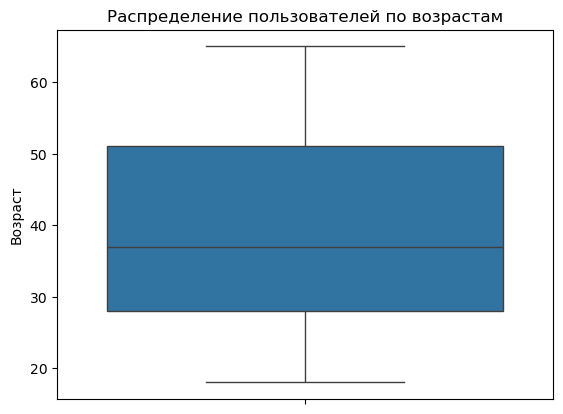

In [229]:
boxplot = sns.boxplot(users_info_cl['age'])
boxplot.axes.set_title("Распределение пользователей по возрастам")
boxplot.set_ylabel("Возраст")

In [12]:
Q1 = np.percentile(users_info_cl['age'], 25)
Q3 = np.percentile(users_info_cl['age'], 75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print (lower_bound, upper_bound) ## Верхняя граница очень высокая - заведомо выше максимального значения возраста, т.е. данные очень компактные

-6.5 85.5


In [14]:
users_info_cl1 = users_info_cl.loc[users_info_cl['age'] < upper_bound].copy()
users_info_cl1.info() ## Ничего не удалили, что и требовалось доказать

<class 'pandas.core.frame.DataFrame'>
Index: 865 entries, 0 to 999
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   id_user  865 non-null    int64  
 1   city     865 non-null    object 
 2   age      865 non-null    float64
 3   gender   865 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 33.8+ KB


Text(0, 0.5, 'Количество')

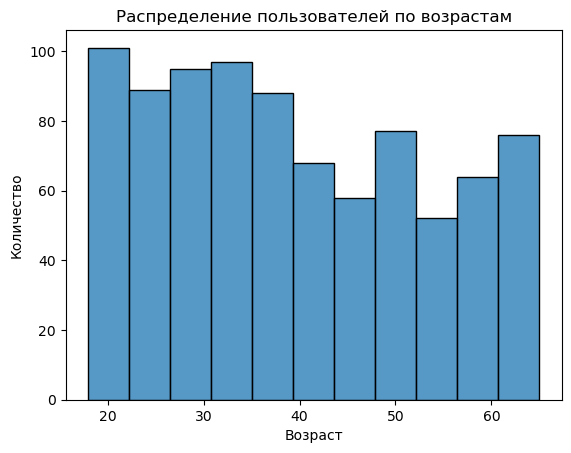

In [36]:
histplot = sns.histplot(users_info_cl1, x = "age") ## Гистограмма распределения пользователей по возрастам
histplot.axes.set_title("Распределение пользователей по возрастам")
histplot.set_xlabel("Возраст")
histplot.set_ylabel("Количество")
# plt.savefig('Age_distr.png',
#             dpi=300,
#             bbox_inches='tight'
#             )

# plt.close()

### Задача 2. Доля пользователей-женщин по городам

In [20]:
users_info_cl1.groupby(['city', 'gender']).agg(cnt_us = ('id_user', 'count')).reset_index()


,city,gender,cnt_us
0,Екатеринбург,female,55
1,Екатеринбург,male,78
2,Казань,female,53
3,Казань,male,77
4,Москва,female,220
5,Москва,male,105
6,СПб,female,123
7,СПб,male,154


In [22]:
pivot_user = pd.pivot_table(users_info_cl1, index = ['city'],\
columns = 'gender', \
values = 'id_user', \
aggfunc = 'count', 
fill_value = 0).reset_index()
pivot_user

gender,city,female,male
0,Екатеринбург,55,78
1,Казань,53,77
2,Москва,220,105
3,СПб,123,154


In [24]:
pivot_user.columns = ['city', 'cnt_female', 'cnt_male']
pivot_user

,city,cnt_female,cnt_male
0,Екатеринбург,55,78
1,Казань,53,77
2,Москва,220,105
3,СПб,123,154


In [26]:
pivot_user['fem_sh'] = round (pivot_user['cnt_female'] / (pivot_user['cnt_female'] + pivot_user['cnt_male']),2)
pivot_user

,city,cnt_female,cnt_male,fem_sh
0,Екатеринбург,55,78,0.41
1,Казань,53,77,0.41
2,Москва,220,105,0.68
3,СПб,123,154,0.44


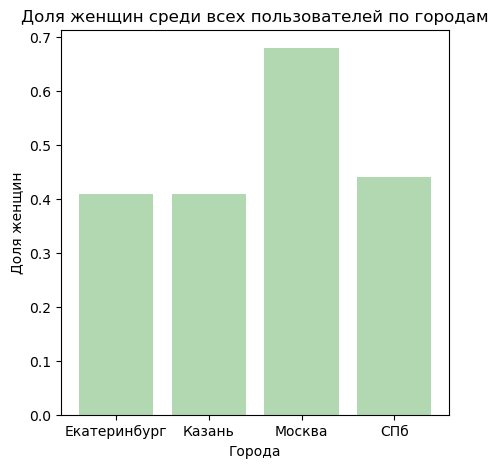

In [32]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))
ax.bar(pivot_user['city'], pivot_user['fem_sh'], alpha = .3, color = 'green')
ax.set_xlabel('Города')
ax.set_ylabel('Доля женщин')
ax.set_title('Доля женщин среди всех пользователей по городам')
# plt.savefig('Female_share.png',
#             dpi=300,
#             bbox_inches='tight'
#             )

# plt.close()
plt.show() ## Доля женщин среди всех пользователей в Москве превышает таковую в других городах

### Задача 3. Делим пользователей на бины

In [38]:
pay_mon = pd.read_csv('payments_monthly.csv')
pay_mon.head()

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total
0,1000,2023-03,0,2,0,3600,2,3600
1,1000,2023-04,0,4,0,7200,4,7200
2,1000,2023-05,0,4,0,6400,4,6400
3,1000,2023-06,0,2,0,3600,2,3600
4,1000,2023-07,0,4,0,7200,4,7200


In [126]:
pay_mon.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5293 entries, 0 to 5292
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id_user    5293 non-null   int64 
 1   mon        5293 non-null   object
 2   cnt_group  5293 non-null   int64 
 3   cnt_indiv  5293 non-null   int64 
 4   sum_group  5293 non-null   int64 
 5   sum_indiv  5293 non-null   int64 
 6   cnt_total  5293 non-null   int64 
 7   sum_total  5293 non-null   int64 
dtypes: int64(7), object(1)
memory usage: 330.9+ KB


In [40]:
users_tr = pay_mon.groupby('id_user').agg(cnt_tr = ('cnt_total', 'sum'), cnt_mon = ('mon', 'count')).reset_index()
users_tr['avg_tr'] = round(users_tr['cnt_tr'] / users_tr['cnt_mon'],0)
users_tr.head()

,id_user,cnt_tr,cnt_mon,avg_tr
0,1000,33,9,4.0
1,1001,129,11,12.0
2,1002,128,11,12.0
3,1003,31,6,5.0
4,1004,18,9,2.0


In [311]:
users_tr['avg_tr'].describe()

count    969.000000
mean       6.373581
std        3.571114
min        1.000000
25%        4.000000
50%        6.000000
75%        9.000000
max       18.000000
Name: avg_tr, dtype: float64

In [42]:
bins = [] 
bins.insert(0, users_tr['avg_tr'].min())
bins.insert(1, np.percentile(users_tr['avg_tr'], 25))
bins.insert(2, np.percentile(users_tr['avg_tr'], 75))
bins.insert(3, np.inf)
print (bins)
labels = ["low", "average", "high"]

[1.0, 4.0, 9.0, inf]


In [315]:
users_tr['user_group'] = pd.cut(
    x=users_tr['avg_tr'],
    bins=bins,
    labels=labels,
    include_lowest=True
)
users_tr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 969 entries, 0 to 968
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   id_user     969 non-null    int64   
 1   cnt_tr      969 non-null    int64   
 2   cnt_mon     969 non-null    int64   
 3   avg_tr      969 non-null    float64 
 4   user_group  969 non-null    category
dtypes: category(1), float64(1), int64(3)
memory usage: 31.5 KB


In [196]:
users_tr.groupby('user_group', observed=False).agg(cnt_user = ('id_user', 'count')).reset_index()

,user_group,cnt_user
0,low,370
1,average,376
2,high,223
